# Seasonal Agriculture Performance Analysis

In [1]:
import csv, math, statistics
from collections import Counter
from pathlib import Path
import numpy as np
from scipy import stats
import statsmodels.api as sm
import matplotlib.pyplot as plt

DATA_PATH = Path('seasonal_agriculture_performance_dataset.csv')
FIG_DIR = Path('figures'); FIG_DIR.mkdir(exist_ok=True)

with open(DATA_PATH, newline='', encoding='utf-8-sig') as f:
    rows = list(csv.DictReader(f))
fields = list(rows[0].keys())
cat_fields = ['Farm_ID','State','District','Crop','Season','Irrigation_Method']
num_fields = [f for f in fields if f not in cat_fields]

print(f'Rows: {len(rows):,} | Columns: {len(fields)}')
print('Numeric fields:', len(num_fields))


Matplotlib is building the font cache; this may take a moment.


Rows: 4,000 | Columns: 28
Numeric fields: 22


## 1. Dataset Understanding

The dataset contains farm-level records with geography, crop and season, environmental variables, soil nutrients, irrigation and farm inputs, yield/production, market price, cost/revenue/profit, water usage/efficiency, and disease/pest risk.

In [2]:
def values(field, subset=rows):
    return np.array([float(r[field]) if r[field] != '' else np.nan for r in subset], dtype=float)

def clean(x): return x[~np.isnan(x)]

def summary(x):
    z = clean(x)
    q1, q3 = np.percentile(z, [25, 75])
    return {'n': len(z), 'missing': int(np.isnan(x).sum()), 'mean': z.mean(), 'median': np.median(z), 'sd': z.std(ddof=1),
            'min': z.min(), 'q1': q1, 'q3': q3, 'max': z.max()}

for f in ['State','District','Crop','Season','Irrigation_Method']:
    print(f'\n{f}:')
    print(Counter(r[f] for r in rows))

missing = {f: sum(r[f] == '' for r in rows) for f in fields}
print('\nMissing values:', {k:v for k,v in missing.items() if v})
print('Duplicate Farm_IDs:', len(rows) - len(set(r['Farm_ID'] for r in rows)))



State:
Counter({'Andhra Pradesh': 529, 'Telangana': 516, 'Maharashtra': 512, 'Madhya Pradesh': 497, 'Karnataka': 489, 'Gujarat': 488, 'Tamil Nadu': 485, 'Punjab': 484})

District:
Counter({'Ludhiana': 427, 'Warangal': 422, 'Nalgonda': 415, 'Erode': 403, 'Rajkot': 401, 'Krishna': 393, 'Indore': 392, 'Guntur': 390, 'Raichur': 386, 'Nashik': 371})

Crop:
Counter({'Rice': 690, 'Wheat': 614, 'Maize': 551, 'Cotton': 508, 'Pulses': 496, 'Groundnut': 424, 'Chilli': 412, 'Sugarcane': 305})

Season:
Counter({'Kharif': 1779, 'Rabi': 1627, 'Zaid': 594})

Irrigation_Method:
Counter({'Flood': 1310, 'Rainfed': 1041, 'Drip': 915, 'Sprinkler': 734})

Missing values: {'Rainfall_mm': 48, 'Soil_Moisture_pct': 40, 'Yield_Tonnes_Ha': 32}
Duplicate Farm_IDs: 0


In [3]:
print('Numeric summary')
for f in num_fields:
    s=summary(values(f))
    print(f"{f:36s} mean={s['mean']:.3f} median={s['median']:.3f} sd={s['sd']:.3f} min={s['min']:.3f} max={s['max']:.3f} missing={s['missing']}")


Numeric summary
Farm_Area_Hectares                   mean=7.888 median=7.895 sd=4.224 min=0.500 max=15.000 missing=0
Rainfall_mm                          mean=601.153 median=582.000 sd=288.925 min=80.000 max=1395.200 missing=48
Avg_Temperature_C                    mean=26.819 median=26.900 sd=3.818 min=16.200 max=39.700 missing=0
Humidity_pct                         mean=63.211 median=63.000 sd=11.961 min=25.000 max=95.000 missing=0
Sunlight_Hours_Day                   mean=7.323 median=7.300 sd=1.121 min=3.500 max=11.000 missing=0
Soil_pH                              mean=6.701 median=6.690 sd=0.641 min=5.200 max=8.400 missing=0
Soil_Moisture_pct                    mean=26.508 median=26.400 sd=6.712 min=8.000 max=47.000 missing=40
Nitrogen_kg_ha                       mean=120.251 median=120.100 sd=31.216 min=40.000 max=220.000 missing=0
Phosphorus_kg_ha                     mean=57.782 median=57.500 sd=17.015 min=15.000 max=120.000 missing=0
Potassium_kg_ha                      mean=10

## 2. Data Quality and Preparation

For descriptive summaries, each metric uses all non-missing observations for that metric. No synthetic values are inserted into the raw dataset. For multivariable regression, complete cases across the selected predictors are used.

Quality checks also test whether arithmetic fields behave consistently with the dataset relationships: `Production ≈ Area × Yield`, `Revenue ≈ Production × Market Price`, `Profit = Revenue − Cost`, and `Water Efficiency ≈ Production / Water Used × 1000`.

In [4]:
# Formula integrity checks
prod=values('Production_Tonnes'); area=values('Farm_Area_Hectares'); y=values('Yield_Tonnes_Ha')
price=values('Market_Price_INR_Tonne'); rev=values('Revenue_INR'); cost=values('Total_Cost_INR'); profit=values('Profit_INR')
water=values('Water_Used_m3'); eff=values('Water_Efficiency_t_per_1000m3')
checks=[('Production',prod,area*y),('Revenue',rev,prod*price),('Profit',profit,rev-cost),('Water efficiency',eff,(prod/water)*1000)]
for name,a,b in checks:
    m=~np.isnan(a)&~np.isnan(b); d=np.abs(a[m]-b[m])
    print(f'{name:18s}: n={m.sum()} | mean abs diff={d.mean():.6f} | max abs diff={d.max():.6f} | within 1 unit={np.mean(d<=1)*100:.2f}%')


Production        : n=3968 | mean abs diff=0.002487 | max abs diff=0.005000 | within 1 unit=100.00%
Revenue           : n=4000 | mean abs diff=0.244630 | max abs diff=0.500000 | within 1 unit=100.00%
Profit            : n=4000 | mean abs diff=0.000000 | max abs diff=0.000000 | within 1 unit=100.00%
Water efficiency  : n=4000 | mean abs diff=0.000250 | max abs diff=0.000500 | within 1 unit=100.00%


### Data-quality caution

Some records contain state–district combinations that appear internally inconsistent (for example, the first row pairs **Andhra Pradesh** with **Rajkot**). Because this project brief is about seasonal agricultural performance rather than geographic validation, the analysis does not rewrite those labels; regional findings should be treated as findings about the supplied dataset.

## 3. Analytical Questions

1. How do environmental conditions differ across Kharif, Rabi and Zaid?
2. Does yield differ meaningfully across seasons?
3. How does farm profitability vary by season?
4. How does water efficiency vary across seasons?
5. Does disease/pest risk change across seasons?
6. Does crop type interact with season in explaining yield and profit?
7. How are irrigation methods associated with yield, water use, efficiency and profit?
8. Which environmental/input variables are associated with yield and profit?
9. How do outcomes vary across states in the supplied data?
10. What unusual/outlier patterns and data-quality issues should be documented?

## 4. Seasonal Environmental Profile

In [5]:
seasons=sorted({r['Season'] for r in rows})
season_fields=['Rainfall_mm','Avg_Temperature_C','Humidity_pct','Sunlight_Hours_Day','Soil_Moisture_pct','Seed_Quality_Score']
for s in seasons:
    rr=[r for r in rows if r['Season']==s]
    print(f'\n{s} (n={len(rr)})')
    for f in season_fields:
        z=clean(values(f,rr)); print(f'  {f:25s} mean={z.mean():.3f} median={np.median(z):.3f}')



Kharif (n=1779)
  Rainfall_mm               mean=852.084 median=854.750
  Avg_Temperature_C         mean=28.454 median=28.500
  Humidity_pct              mean=71.813 median=71.900
  Sunlight_Hours_Day        mean=6.793 median=6.800
  Soil_Moisture_pct         mean=31.198 median=31.200
  Seed_Quality_Score        mean=0.822 median=0.820

Rabi (n=1627)
  Rainfall_mm               mean=436.000 median=430.300
  Avg_Temperature_C         mean=23.489 median=23.500
  Humidity_pct              mean=57.893 median=58.100
  Sunlight_Hours_Day        mean=7.590 median=7.600
  Soil_Moisture_pct         mean=24.051 median=24.000
  Seed_Quality_Score        mean=0.832 median=0.840

Zaid (n=594)
  Rainfall_mm               mean=299.422 median=283.300
  Avg_Temperature_C         mean=31.042 median=31.000
  Humidity_pct              mean=52.012 median=52.350
  Sunlight_Hours_Day        mean=8.179 median=8.200
  Soil_Moisture_pct         mean=19.170 median=19.100
  Seed_Quality_Score        mean=0.823 m

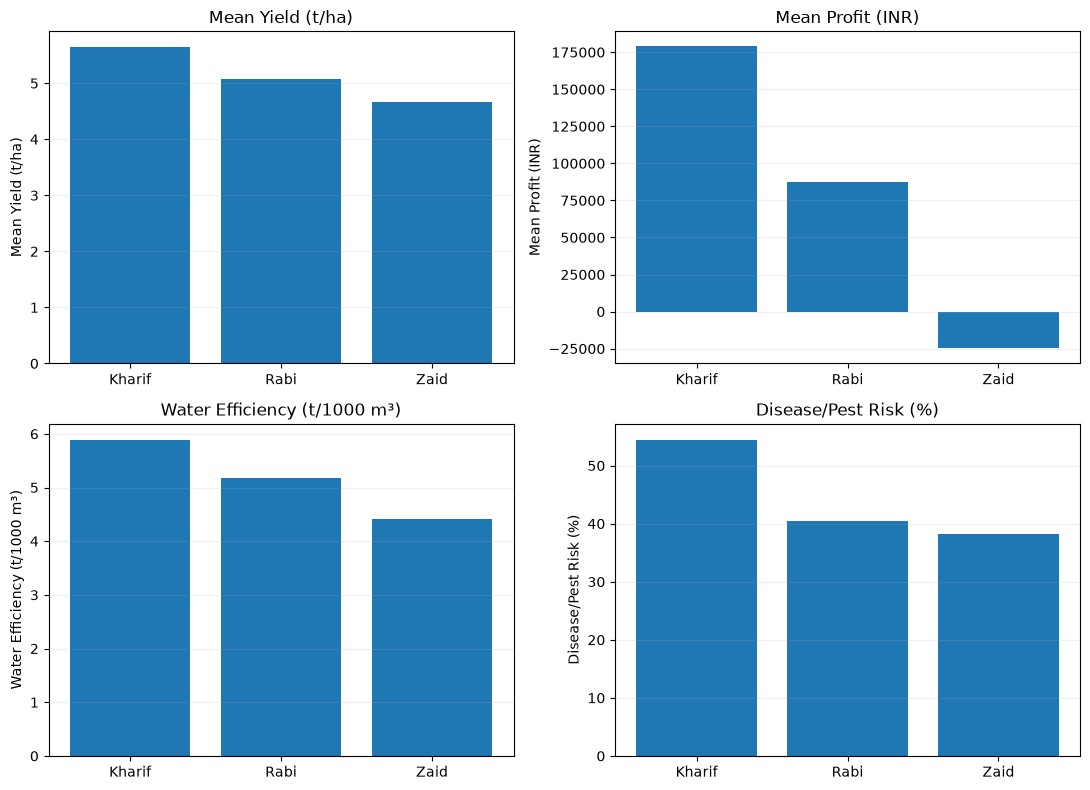

In [6]:
# Seasonal KPI comparison
metrics=[('Yield_Tonnes_Ha','Mean Yield (t/ha)'),('Profit_INR','Mean Profit (INR)'),('Water_Efficiency_t_per_1000m3','Water Efficiency (t/1000 m³)'),('Disease_Pest_Risk_pct','Disease/Pest Risk (%)')]
fig, axes = plt.subplots(2,2,figsize=(11,8))
for ax,(f,title) in zip(axes.flat,metrics):
    yv=[clean(values(f,[r for r in rows if r['Season']==s])).mean() for s in seasons]
    ax.bar(seasons,yv); ax.set_title(title); ax.set_ylabel(title); ax.grid(axis='y',alpha=.2)
fig.tight_layout(); fig.savefig(FIG_DIR/'seasonal_kpis.png',dpi=160); plt.show()


## 5. Seasonal Performance Results

In [7]:
targets=['Yield_Tonnes_Ha','Profit_INR','Water_Efficiency_t_per_1000m3','Disease_Pest_Risk_pct']
for s in seasons:
    rr=[r for r in rows if r['Season']==s]
    print(f'{s:7s}', end=' | ')
    for f in targets:
        z=clean(values(f,rr)); print(f'{f}: mean={z.mean():.3f}, median={np.median(z):.3f}', end=' | ')
    p=clean(values('Profit_INR',rr)); print(f'positive profit={np.mean(p>0)*100:.2f}%')


Kharif  | Yield_Tonnes_Ha: mean=5.644, median=1.950 | Profit_INR: mean=178914.648, median=38808.000 | Water_Efficiency_t_per_1000m3: mean=5.892, median=3.277 | Disease_Pest_Risk_pct: mean=54.468, median=54.500 | positive profit=57.79%
Rabi    | Yield_Tonnes_Ha: mean=5.080, median=1.660 | Profit_INR: mean=87689.470, median=-3187.000 | Water_Efficiency_t_per_1000m3: mean=5.186, median=2.740 | Disease_Pest_Risk_pct: mean=40.482, median=40.600 | positive profit=48.86%
Zaid    | Yield_Tonnes_Ha: mean=4.666, median=1.450 | Profit_INR: mean=-24804.825, median=-62144.000 | Water_Efficiency_t_per_1000m3: mean=4.413, median=2.301 | Disease_Pest_Risk_pct: mean=38.217, median=37.900 | positive profit=35.52%


### Statistical tests: season differences

Because yield and profit are strongly right-skewed, the notebook reports both one-way ANOVA and Kruskal–Wallis tests. The non-parametric test is especially useful for checking whether season distributions differ without relying on normality.

In [8]:
for target in targets:
    groups=[clean(values(target,[r for r in rows if r['Season']==s])) for s in seasons]
    F,p=stats.f_oneway(*groups); H,pkw=stats.kruskal(*groups)
    print(f'{target:36s} ANOVA p={p:.3g} | Kruskal-Wallis p={pkw:.3g}')

print('\nPairwise Welch tests with Bonferroni adjustment:')
for target in ['Profit_INR','Water_Efficiency_t_per_1000m3','Disease_Pest_Risk_pct']:
    print('\n',target)
    comparisons=[]
    for i,a in enumerate(seasons):
        for b in seasons[i+1:]:
            xa=clean(values(target,[r for r in rows if r['Season']==a])); xb=clean(values(target,[r for r in rows if r['Season']==b]))
            t,p=stats.ttest_ind(xa,xb,equal_var=False); comparisons.append((a,b,p))
    m=len(comparisons)
    for a,b,p in comparisons: print(f'  {a} vs {b}: p={min(p*m,1):.3g}')


Yield_Tonnes_Ha                      ANOVA p=0.233 | Kruskal-Wallis p=1.27e-15
Profit_INR                           ANOVA p=1.71e-15 | Kruskal-Wallis p=7.36e-23
Water_Efficiency_t_per_1000m3        ANOVA p=0.000972 | Kruskal-Wallis p=4.61e-13
Disease_Pest_Risk_pct                ANOVA p=0 | Kruskal-Wallis p=1.91e-311

Pairwise Welch tests with Bonferroni adjustment:

 Profit_INR
  Kharif vs Rabi: p=4.43e-06
  Kharif vs Zaid: p=8.13e-18
  Rabi vs Zaid: p=7.06e-07

 Water_Efficiency_t_per_1000m3
  Kharif vs Rabi: p=0.069
  Kharif vs Zaid: p=0.000183
  Rabi vs Zaid: p=0.0827

 Disease_Pest_Risk_pct
  Kharif vs Rabi: p=9.24e-291
  Kharif vs Zaid: p=3.98e-174
  Rabi vs Zaid: p=6.73e-06


**Interpretation:** Seasonal environmental conditions differ clearly in the supplied data: Kharif has the highest rainfall, humidity and soil moisture; Zaid has the highest average temperature and sunlight. Profit and water efficiency also show overall season differences. Yield is more complicated: its raw distribution is extremely skewed, and the ANOVA and Kruskal–Wallis tests do not tell the same story. This motivates controlling for crop type in the next section rather than making a simple season-only claim about yield.

## 6. Crop × Season Interaction

In [9]:
crops=sorted({r['Crop'] for r in rows})
for s in seasons:
    print(f'\n{s}')
    for c in crops:
        rr=[r for r in rows if r['Season']==s and r['Crop']==c]
        y=clean(values('Yield_Tonnes_Ha',rr)); p=clean(values('Profit_INR',rr))
        print(f'  {c:11s} n={len(rr):3d} yield={y.mean():8.3f} t/ha profit={p.mean():12.0f} INR')



Kharif
  Chilli      n=185 yield=   1.731 t/ha profit=      954380 INR
  Cotton      n=215 yield=   1.373 t/ha profit=      217000 INR
  Groundnut   n=193 yield=   1.484 t/ha profit=      108265 INR
  Maize       n=234 yield=   2.966 t/ha profit=      -39333 INR
  Pulses      n=221 yield=   1.036 t/ha profit=       43339 INR
  Rice        n=314 yield=   2.708 t/ha profit=      -64903 INR
  Sugarcane   n=125 yield=  53.459 t/ha profit=     1000791 INR
  Wheat       n=292 yield=   2.255 t/ha profit=     -105872 INR

Rabi
  Chilli      n=163 yield=   1.462 t/ha profit=      638572 INR
  Cotton      n=201 yield=   1.193 t/ha profit=      107344 INR
  Groundnut   n=177 yield=   1.221 t/ha profit=       10417 INR
  Maize       n=233 yield=   2.615 t/ha profit=      -89133 INR
  Pulses      n=213 yield=   0.872 t/ha profit=      -14309 INR
  Rice        n=274 yield=   2.334 t/ha profit=      -98428 INR
  Sugarcane   n=129 yield=  43.940 t/ha profit=      731613 INR
  Wheat       n=237 yield=

In [10]:
def design_matrix(rr, include_season=True, include_crop=True, interaction=False):
    X=[np.ones(len(rr))]; names=['Intercept']
    if include_season:
        for s in seasons[1:]: X.append(np.array([r['Season']==s for r in rr],float)); names.append('Season='+s)
    if include_crop:
        for c in crops[1:]: X.append(np.array([r['Crop']==c for r in rr],float)); names.append('Crop='+c)
    if interaction:
        for s in seasons[1:]:
            for c in crops[1:]: X.append(np.array([(r['Season']==s and r['Crop']==c) for r in rr],float)); names.append(f'Interaction={s}:{c}')
    return np.column_stack(X),names

def sse(y,X):
    beta=np.linalg.lstsq(X,y,rcond=None)[0]; return np.sum((y-X@beta)**2), X.shape[1]

def partial_f(y, Xr, Xf):
    sser,dfr=sse(y,Xr); ssef,dff=sse(y,Xf); q=dff-dfr; df2=len(y)-dff
    F=((sser-ssef)/q)/(ssef/df2); return F, stats.f.sf(F,q,df2)

for target in ['Yield_Tonnes_Ha','Profit_INR']:
    rr=[r for r in rows if r[target] != '']; y=values(target,rr)
    Xs,_=design_matrix(rr,True,False); Xc,_=design_matrix(rr,False,True); Xsc,_=design_matrix(rr,True,True); Xfull,_=design_matrix(rr,True,True,True)
    Fs,ps=partial_f(y,Xc,Xsc); Fc,pc=partial_f(y,Xs,Xsc); Fi,pi=partial_f(y,Xsc,Xfull)
    ssef,_=sse(y,Xfull); r2=1-ssef/np.sum((y-y.mean())**2)
    print(f'{target}: Season F={Fs:.2f}, p={ps:.3g}; Crop F={Fc:.2f}, p={pc:.3g}; Interaction F={Fi:.2f}, p={pi:.3g}; R²={r2:.3f}')


Yield_Tonnes_Ha: Season F=22.57, p=1.79e-10; Crop F=2384.95, p=0; Interaction F=19.45, p=4.25e-48; R²=0.821
Profit_INR: Season F=64.78, p=2.05e-28; Crop F=319.57, p=0; Interaction F=4.39, p=7.56e-08; R²=0.380


**Interpretation:** Crop type contributes very large variation in yield and profit, and the season × crop interaction is statistically significant for both outcomes. That means seasonal performance is not uniform across crops; the effect of season depends on which crop is being considered.

## 7. Irrigation Method Analysis

Drip       n= 915 | yield=6.621 | water=5918.7 m³ | efficiency=6.267 | profit=219626
Flood      n=1310 | yield=4.898 | water=8026.5 m³ | efficiency=3.439 | profit=73354
Rainfed    n=1041 | yield=4.613 | water=3549.6 m³ | efficiency=7.564 | profit=79050
Sprinkler  n= 734 | yield=5.189 | water=6208.3 m³ | efficiency=4.670 | profit=91121


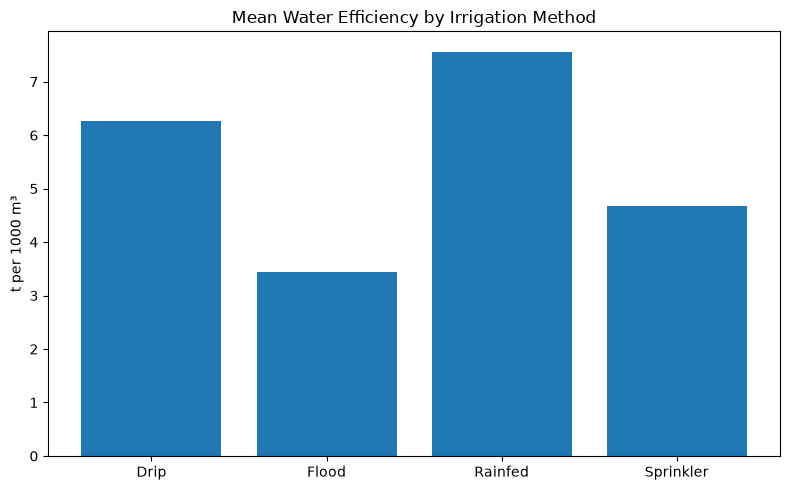

In [11]:
irrigation=sorted({r['Irrigation_Method'] for r in rows})
for method in irrigation:
    rr=[r for r in rows if r['Irrigation_Method']==method]
    y=clean(values('Yield_Tonnes_Ha',rr)); w=clean(values('Water_Used_m3',rr)); e=clean(values('Water_Efficiency_t_per_1000m3',rr)); p=clean(values('Profit_INR',rr))
    print(f'{method:10s} n={len(rr):4d} | yield={y.mean():.3f} | water={w.mean():.1f} m³ | efficiency={e.mean():.3f} | profit={p.mean():.0f}')

fig,ax=plt.subplots(figsize=(8,5));
e=[clean(values('Water_Efficiency_t_per_1000m3',[r for r in rows if r['Irrigation_Method']==m])).mean() for m in irrigation]
ax.bar(irrigation,e); ax.set_title('Mean Water Efficiency by Irrigation Method'); ax.set_ylabel('t per 1000 m³'); fig.tight_layout(); fig.savefig(FIG_DIR/'water_efficiency_by_irrigation.png',dpi=160); plt.show()


**Interpretation:** The observed irrigation groups differ in both resource use and outcomes. These are observational comparisons; irrigation method may be associated with crop, season, farm size, or other factors, so the raw group means should not be interpreted as causal treatment effects.

## 8. Correlation and Multivariable Regression

In [12]:
candidate=['Rainfall_mm','Avg_Temperature_C','Humidity_pct','Sunlight_Hours_Day','Soil_pH','Soil_Moisture_pct','Nitrogen_kg_ha','Phosphorus_kg_ha','Potassium_kg_ha','Fertilizer_kg_ha','Pesticide_Litre_ha','Seed_Quality_Score','Market_Price_INR_Tonne','Total_Cost_INR','Water_Used_m3','Disease_Pest_Risk_pct','Farm_Area_Hectares']
for target in ['Yield_Tonnes_Ha','Profit_INR']:
    print(f'\nTop Pearson correlations with {target}:')
    out=[]; t=values(target)
    for f in candidate:
        x=values(f); m=~np.isnan(t)&~np.isnan(x); r,p=stats.pearsonr(t[m],x[m]); out.append((abs(r),f,r,p))
    for _,f,r,p in sorted(out,reverse=True)[:8]: print(f'  {f:30s} r={r: .3f} p={p:.3g}')



Top Pearson correlations with Yield_Tonnes_Ha:
  Water_Used_m3                  r= 0.389 p=3.05e-143
  Market_Price_INR_Tonne         r=-0.384 p=7.78e-140
  Nitrogen_kg_ha                 r= 0.054 p=0.000687
  Phosphorus_kg_ha               r= 0.048 p=0.00259
  Rainfall_mm                    r= 0.031 p=0.0534
  Total_Cost_INR                 r= 0.031 p=0.0523
  Farm_Area_Hectares             r= 0.030 p=0.0572
  Soil_pH                        r=-0.021 p=0.193

Top Pearson correlations with Profit_INR:
  Market_Price_INR_Tonne         r= 0.225 p=3.94e-47
  Water_Used_m3                  r= 0.190 p=6.36e-34
  Farm_Area_Hectares             r= 0.115 p=2.66e-13
  Rainfall_mm                    r= 0.108 p=9.51e-12
  Soil_Moisture_pct              r= 0.092 p=7.27e-09
  Nitrogen_kg_ha                 r= 0.085 p=7.25e-08
  Fertilizer_kg_ha               r=-0.074 p=3.22e-06
  Total_Cost_INR                 r= 0.068 p=1.51e-05


### Yield regression

The following OLS model uses environmental conditions, soil nutrients, farm inputs, water use, seed quality and disease/pest risk as predictors. It is intended as an association model, not a causal model.

In [13]:
yield_predictors=['Rainfall_mm','Avg_Temperature_C','Humidity_pct','Sunlight_Hours_Day','Soil_pH','Soil_Moisture_pct','Nitrogen_kg_ha','Phosphorus_kg_ha','Potassium_kg_ha','Fertilizer_kg_ha','Pesticide_Litre_ha','Seed_Quality_Score','Water_Used_m3','Disease_Pest_Risk_pct']
X=np.column_stack([values(f) for f in yield_predictors]); y=values('Yield_Tonnes_Ha'); m=~np.isnan(y)&~np.isnan(X).any(axis=1); model=sm.OLS(y[m],sm.add_constant(X[m])).fit()
print(f'n={m.sum()} R²={model.rsquared:.3f} adjusted R²={model.rsquared_adj:.3f}')
for f,b,p in zip(yield_predictors,model.params[1:],model.pvalues[1:]): print(f'{f:30s} coef={b: .5f} p={p:.3g}')


n=3880 R²=0.159 adjusted R²=0.156
Rainfall_mm                    coef= 0.00217 p=0.038
Avg_Temperature_C              coef=-0.00887 p=0.869
Humidity_pct                   coef= 0.01166 p=0.592
Sunlight_Hours_Day             coef=-0.10179 p=0.594
Soil_pH                        coef=-0.28935 p=0.346
Soil_Moisture_pct              coef=-0.01841 p=0.605
Nitrogen_kg_ha                 coef= 0.01859 p=0.00315
Phosphorus_kg_ha               coef= 0.03819 p=0.000961
Potassium_kg_ha                coef=-0.00008 p=0.991
Fertilizer_kg_ha               coef=-0.00054 p=0.868
Pesticide_Litre_ha             coef=-0.16840 p=0.192
Seed_Quality_Score             coef=-2.02821 p=0.294
Water_Used_m3                  coef= 0.00094 p=3.55e-141
Disease_Pest_Risk_pct          coef=-0.03654 p=0.194


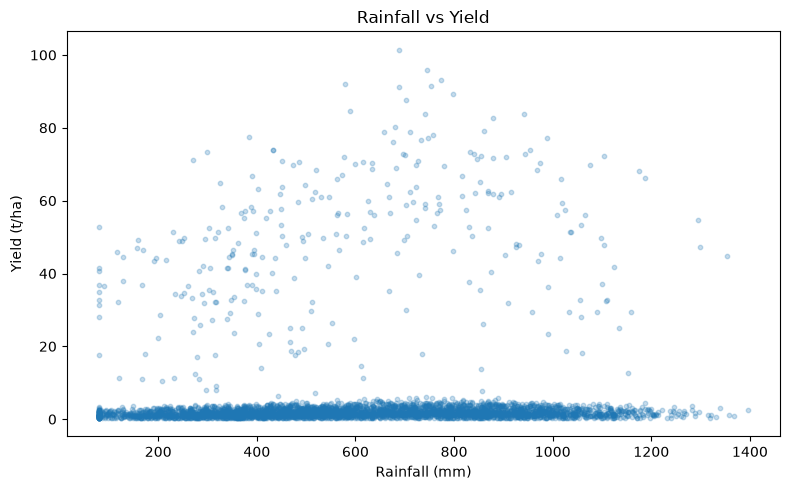

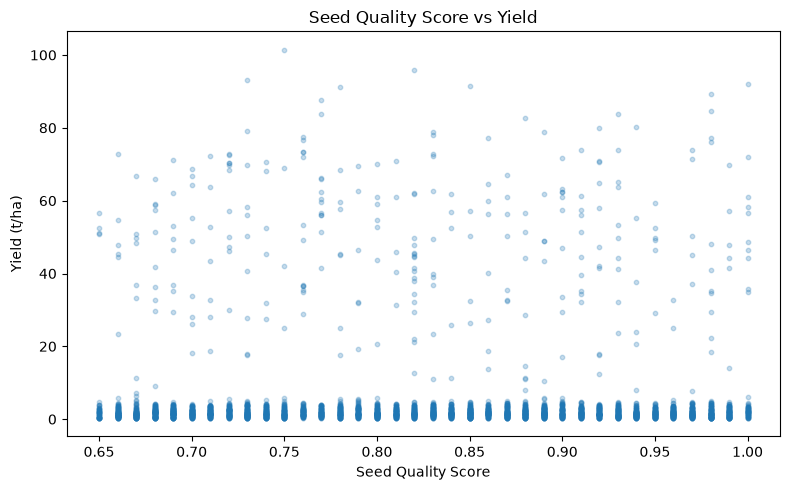

In [14]:
# Visual relationship examples
x=values('Rainfall_mm'); y=values('Yield_Tonnes_Ha'); m=~np.isnan(x)&~np.isnan(y)
fig,ax=plt.subplots(figsize=(8,5)); ax.scatter(x[m],y[m],s=10,alpha=.25); ax.set_title('Rainfall vs Yield'); ax.set_xlabel('Rainfall (mm)'); ax.set_ylabel('Yield (t/ha)'); fig.tight_layout(); fig.savefig(FIG_DIR/'rainfall_vs_yield.png',dpi=160); plt.show()

x=values('Seed_Quality_Score'); y=values('Yield_Tonnes_Ha'); m=~np.isnan(x)&~np.isnan(y)
fig,ax=plt.subplots(figsize=(8,5)); ax.scatter(x[m],y[m],s=10,alpha=.25); ax.set_title('Seed Quality Score vs Yield'); ax.set_xlabel('Seed Quality Score'); ax.set_ylabel('Yield (t/ha)'); fig.tight_layout(); fig.savefig(FIG_DIR/'seed_quality_vs_yield.png',dpi=160); plt.show()


## 9. Regional Variation

The state field is analyzed as supplied, without attempting to correct state–district mappings.

In [15]:
for state in sorted({r['State'] for r in rows}):
    rr=[r for r in rows if r['State']==state]
    y=clean(values('Yield_Tonnes_Ha',rr)); p=clean(values('Profit_INR',rr)); e=clean(values('Water_Efficiency_t_per_1000m3',rr)); risk=clean(values('Disease_Pest_Risk_pct',rr))
    print(f'{state:18s} n={len(rr):3d} yield={y.mean():.3f} profit={p.mean():.0f} efficiency={e.mean():.3f} risk={risk.mean():.2f}')


Andhra Pradesh     n=529 yield=4.651 profit=73454 efficiency=5.031 risk=46.72
Gujarat            n=488 yield=5.700 profit=117568 efficiency=5.579 risk=45.95
Karnataka          n=489 yield=5.734 profit=119422 efficiency=5.562 risk=46.06
Madhya Pradesh     n=497 yield=5.030 profit=86841 efficiency=5.267 risk=47.08
Maharashtra        n=512 yield=5.030 profit=135429 efficiency=5.284 risk=46.44
Punjab             n=484 yield=6.121 profit=136026 efficiency=5.622 risk=46.00
Tamil Nadu         n=485 yield=4.901 profit=117745 efficiency=5.305 risk=46.28
Telangana          n=516 yield=5.077 profit=108830 efficiency=5.465 risk=46.36


## 10. Outliers and Distributional Issues

Yield_Tonnes_Ha                        Q1=1.050 Q3=2.840 upper fence=5.525 outliers=302 (7.61%)
Profit_INR                             Q1=-148731.750 Q3=216187.750 upper fence=763567.000 outliers=404 (10.10%)
Water_Efficiency_t_per_1000m3          Q1=1.661 Q3=5.150 upper fence=10.384 outliers=322 (8.05%)
Disease_Pest_Risk_pct                  Q1=37.300 Q3=54.900 upper fence=81.300 outliers=10 (0.25%)


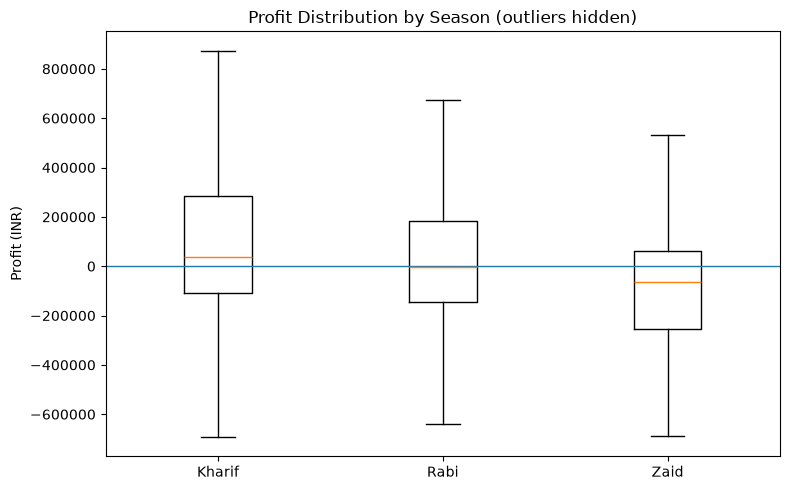

In [20]:
for f in ['Yield_Tonnes_Ha','Profit_INR','Water_Efficiency_t_per_1000m3','Disease_Pest_Risk_pct']:
    z=clean(values(f)); q1,q3=np.percentile(z,[25,75]); iqr=q3-q1; lo=q1-1.5*iqr; hi=q3+1.5*iqr; out=np.sum((z<lo)|(z>hi))
    print(f'{f:38s} Q1={q1:.3f} Q3={q3:.3f} upper fence={hi:.3f} outliers={out} ({out/len(z)*100:.2f}%)')

fig,ax=plt.subplots(figsize=(8,5)); data=[clean(values('Profit_INR',[r for r in rows if r['Season']==s])) for s in seasons]; ax.boxplot(data,tick_labels=seasons,showfliers=False); ax.axhline(0,linewidth=1); ax.set_title('Profit Distribution by Season (outliers hidden)'); ax.set_ylabel('Profit (INR)'); fig.tight_layout(); fig.savefig(FIG_DIR/'profit_distribution_by_season.png',dpi=160); plt.show()


## 11. Key Findings

- The dataset contains **4,000 farm records and 28 columns**. Missingness is limited to rainfall (48), soil moisture (40), and yield (32).
- Kharif has the highest mean rainfall (852.1 mm), humidity (71.8%), soil moisture (31.2%), mean profit (₹178,915), water efficiency (5.892 t/1000 m³), and disease/pest risk (54.47%) among the three seasons.
- Zaid has the highest mean temperature (31.0 °C) and sunlight (8.18 h/day), but the lowest mean profit (−₹24,805) and water efficiency (4.413).
- Yield is highly skewed because of very high-yield observations, especially sugarcane. Season-only yield tests are therefore sensitive to the method used.
- The **season × crop interaction is statistically significant** for both yield and profit, supporting crop-specific seasonal analysis.
- Irrigation groups show sizable differences in water use, efficiency, yield and profit, but these are associations rather than controlled treatment effects.
- Arithmetic consistency checks are strong: production, profit and water-efficiency fields match their implied calculations within rounding; revenue also matches within 1 INR in all records.

## 12. Data-Driven Recommendations

1. Use **crop-specific seasonal planning** rather than a single seasonal strategy, because the season × crop interaction is significant.
2. Treat **profit and water efficiency as joint KPIs**, since a season can show reasonable production while still having weak economic or water performance.
3. Investigate irrigation practices at crop-season level before drawing operational conclusions; raw method averages can be confounded by crop mix and farm characteristics.
4. Flag unusually high yield, profit, and water-efficiency records for validation or separate sensitivity analysis instead of removing them automatically.
5. For future data collection, validate the state–district mapping and capture additional variables such as labor, machinery, seed variety, farm ownership, and market-access distance if available.

## 13. Conclusion

The supplied dataset contains enough variation to support a strong seasonal agriculture analytics project. The main analytical lesson is that **season alone does not explain agricultural performance**: environmental conditions vary across seasons, but crop composition, irrigation, and farm-level characteristics also shape observed outcomes. The most defensible project narrative is therefore a layered analysis—seasonal context → crop × season differences → irrigation/resource patterns → statistical relationships → quality checks and recommendations.